# Procurement Planning

Explode finished-goods production through the BOM into raw-material requirements and procurement orders.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
bom = pd.read_csv(PROJECT_ROOT / "data/raw/bom.csv")
raw_materials = pd.read_csv(PROJECT_ROOT / "data/raw/raw_materials.csv")
display(bom.head(20))
display(raw_materials)

,sku,raw_material_id,quantity_per_case
0,BB250,RM001,1.500
1,BB250,RM002,0.300
2,BB250,RM003,0.015
3,BB250,RM004,24.000
4,BB250,RM005,24.000
5,BB250,RM006,24.000
6,BB250,RM007,1.000
7,BB250,RM008,0.080
8,BB500,RM001,3.000
9,BB500,RM002,0.600


,raw_material_id,raw_material_name,unit,unit_cost,lead_time_days,safety_stock_days,moq
0,RM001,Sugar,kg,0.65,7,5,500
1,RM002,Beverage Concentrate,kg,4.50,14,7,100
2,RM003,CO2,kg,1.80,5,3,100
3,RM004,PET Bottle,unit,2.10,10,5,5000
4,RM005,Cap,unit,0.35,10,5,5000
5,RM006,Label,unit,0.12,7,5,10000
6,RM007,Carton,unit,8.50,7,5,500
7,RM008,Shrink Film,kg,2.20,7,5,100


In [3]:
requirements = pd.read_csv(PROJECT_ROOT / "data/processed/raw_material_requirements.csv", parse_dates=["week_start"])
procurement_plan = pd.read_csv(PROJECT_ROOT / "data/processed/procurement_plan.csv", parse_dates=["week_start"])
display(requirements.head(20))
display(procurement_plan.head(20))

,week_start,plant_id,raw_material_id,raw_material_requirement
0,2025-06-30,P01,RM001,8577.569214
1,2025-06-30,P01,RM002,1717.863650
2,2025-06-30,P01,RM003,77.057289
3,2025-06-30,P01,RM004,56684.676240
4,2025-06-30,P01,RM005,56684.676240
5,2025-06-30,P01,RM006,56684.676240
6,2025-06-30,P01,RM007,3126.364670
7,2025-06-30,P01,RM008,331.583534
8,2025-06-30,P02,RM001,28117.209498
9,2025-06-30,P02,RM002,5628.168383


,week_start,plant_id,raw_material_id,raw_material_requirement,raw_material_name,unit,unit_cost,lead_time_days,safety_stock_days,moq,opening_inventory,safety_stock,projected_inventory_before_receipt,planned_order_quantity,ending_inventory,purchase_cost
0,2025-06-30,P01,RM001,8577.569214,Sugar,kg,0.65,7,5,500,18000,6212.387135,9422.430786,0.0,9422.430786,0.0
1,2025-07-07,P01,RM001,9513.417936,Sugar,kg,0.65,7,5,500,18000,6212.387135,-90.987150,6500.0,6409.012850,4225.0
2,2025-07-14,P01,RM001,9638.707863,Sugar,kg,0.65,7,5,500,18000,6212.387135,-3229.695013,9500.0,6270.304987,6175.0
3,2025-07-21,P01,RM001,9577.926408,Sugar,kg,0.65,7,5,500,18000,6212.387135,-3307.621421,10000.0,6692.378579,6500.0
4,2025-07-28,P01,RM001,9083.486010,Sugar,kg,0.65,7,5,500,18000,6212.387135,-2391.107431,9000.0,6608.892569,5850.0
5,2025-08-04,P01,RM001,8651.783643,Sugar,kg,0.65,7,5,500,18000,6212.387135,-2042.891074,8500.0,6457.108926,5525.0
6,2025-08-11,P01,RM001,8765.847051,Sugar,kg,0.65,7,5,500,18000,6212.387135,-2308.738125,9000.0,6691.261875,5850.0
7,2025-08-18,P01,RM001,8633.923908,Sugar,kg,0.65,7,5,500,18000,6212.387135,-1942.662033,8500.0,6557.337967,5525.0
8,2025-08-25,P01,RM001,8870.202513,Sugar,kg,0.65,7,5,500,18000,6212.387135,-2312.864546,9000.0,6687.135454,5850.0
9,2025-09-01,P01,RM001,8576.382831,Sugar,kg,0.65,7,5,500,18000,6212.387135,-1889.247377,8500.0,6610.752623,5525.0


,raw_material_id,quantity,spend
3,RM004,8000000.0,16800000.0
6,RM007,447500.0,3803750.0
4,RM005,8000000.0,2800000.0
1,RM002,242200.0,1089900.0
5,RM006,8010000.0,961200.0
0,RM001,1193500.0,775775.0
7,RM008,47300.0,104060.0
2,RM003,10700.0,19260.0


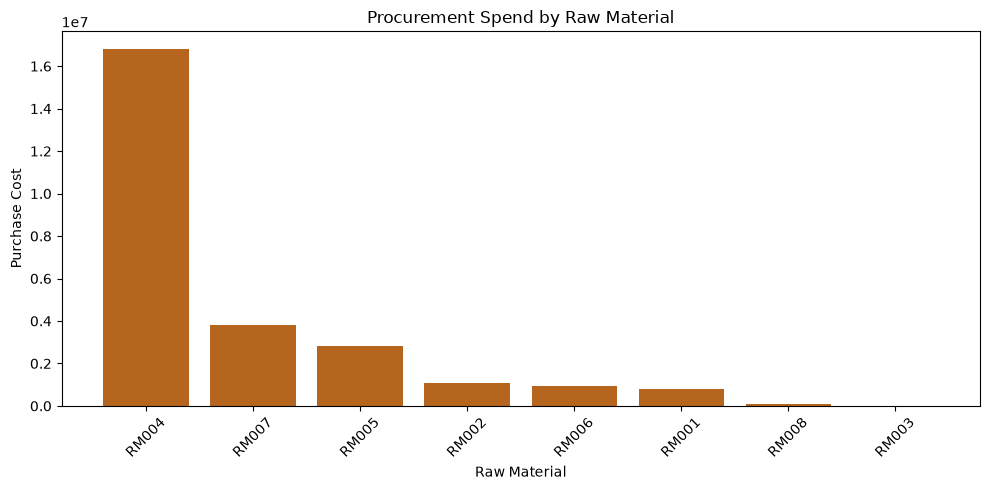

In [4]:
spend = procurement_plan.groupby("raw_material_id", as_index=False).agg(quantity=("planned_order_quantity", "sum"), spend=("purchase_cost", "sum")).sort_values("spend", ascending=False)
display(spend)
plt.figure(figsize=(10, 5))
plt.bar(spend["raw_material_id"], spend["spend"], color="#b5651d")
plt.title("Procurement Spend by Raw Material")
plt.ylabel("Purchase Cost")
plt.xlabel("Raw Material")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

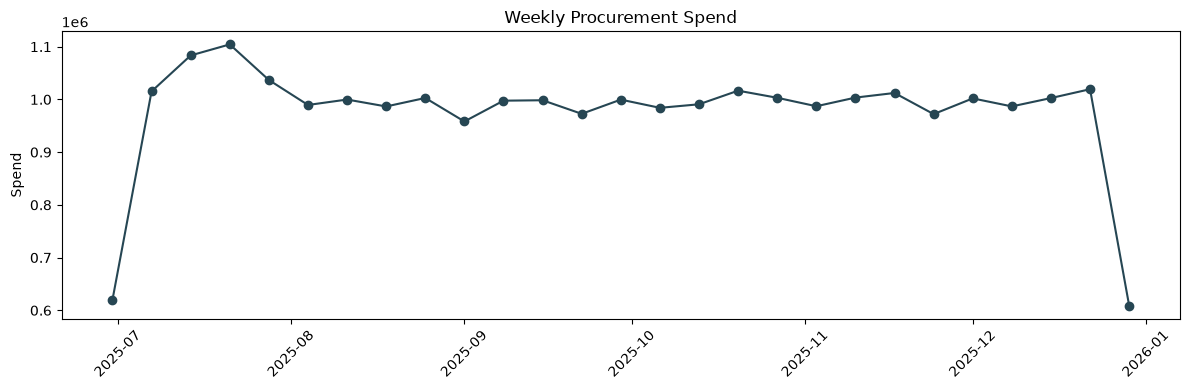

In [5]:
weekly_spend = procurement_plan.groupby("week_start", as_index=False)["purchase_cost"].sum()
plt.figure(figsize=(12, 4))
plt.plot(weekly_spend["week_start"], weekly_spend["purchase_cost"], marker="o", color="#264653")
plt.title("Weekly Procurement Spend")
plt.ylabel("Spend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()